In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
cmap = 'coolwarm'

In [2]:
baseline = pd.read_csv('BCEA_BaselineValues2.csv')
ride = pd.read_csv('BCEA_RideValues2.csv')
fog=pd.read_csv('BCEA_FogValues2.csv')


In [3]:
# Convert 'Gender' to numeric if it exists
for df in [baseline, ride, fog]:
    if 'Gender' in df.columns:
        df['Gender'] = df['Gender'].map({'M': 0, 'F': 1})

# Then select only numeric columns
baseline_num = baseline.select_dtypes(include=[np.number])
ride_num     = ride.select_dtypes(include=[np.number])
fog_num = fog.select_dtypes(include=[np.number])
baseline_num.head()

,MeanHoriz,StdHoriz,MeanVert,StdVert,RHO,BCEA,Estimated PRL,Guziks Index,MSE,Sample Entropy Horiz,App Entropy Horiz,Sample Entropy Vert,App Entropy Vert
0,5.151988,3.126788,8.066502,5.906800,-0.074533,347.169991,2,0.277461,11003.132930,0.060879,0.142565,0.033707,0.129698
1,-24.018464,3.853317,11.428652,3.459394,0.019379,251.220116,3,0.803201,1990.131005,0.162610,0.104444,0.259139,0.117033
2,-2.130202,4.850855,8.002638,6.631971,0.166508,597.938609,3,0.490336,18469.199950,0.050693,0.203427,0.025032,0.163494
3,0.806637,8.946961,6.926136,5.480803,-0.086105,920.883917,2,0.369209,58179.802110,0.060185,0.091366,0.064590,0.108698
4,37.424268,2.326935,9.447647,6.186620,0.181227,266.862287,2,0.135363,13326.135540,0.066141,0.162173,0.030558,0.199578


In [4]:
baseline_num = baseline.select_dtypes(include=[np.number])
ride_num = ride.select_dtypes(include=[np.number])
fog_num = fog.select_dtypes(include=[np.number])


In [5]:
combined = pd.concat([baseline_num, ride_num, fog_num], ignore_index=True).dropna()
corr_combined = combined.corr()
corr_baseline = baseline_num.corr()
corr_ride = ride_num.corr()
corr_fog=fog_num.corr()
mask = np.triu(np.ones_like(corr_combined, dtype=bool))


In [6]:
def basic_stats(df):
    return pd.DataFrame({
        'Mean': df.mean(),
        'Median': df.median(),
        'Min': df.min(),
        'Max': df.max(),
        'Std': df.std()
    })

baseline_stats = basic_stats(baseline_num)
ride_stats     = basic_stats(ride_num)
fog_stats      = basic_stats(fog_num)

# Display the result
print("=== Baseline statistics ===")
print(baseline_stats)
print("\n=== Ride statistics ===")
print(ride_stats)
print("\n=== Fog statistics ===")
print(fog_stats)

combined_stats = pd.concat(
    {'Baseline': baseline_stats, 'Ride': ride_stats, 'Fog': fog_stats},
    axis=1
)
combined_stats

=== Baseline statistics ===
                              Mean        Median        Min           Max  \
MeanHoriz                 4.461636      0.119577 -24.018464     44.379658   
StdHoriz                  5.197088      5.080887   0.497265      8.946961   
MeanVert                  5.325905      7.344171 -24.106646     19.869936   
StdVert                   5.418761      5.609923   1.133709      8.722742   
RHO                       0.050036      0.046461  -0.336521      0.363787   
BCEA                    580.258481    532.285914  10.613949   1267.022488   
Estimated PRL             2.208333      2.000000   1.000000      5.000000   
Guziks Index              0.506493      0.561945   0.071956      0.901619   
MSE                   22966.475372  15213.995655  14.884371  67622.801210   
Sample Entropy Horiz      0.081854      0.060391   0.015664      0.357769   
App Entropy Horiz         0.166565      0.156044   0.091366      0.348203   
Sample Entropy Vert       0.076084      0.058149

Baseline                                         \
                              Mean        Median        Min           Max   
MeanHoriz                 4.461636      0.119577 -24.018464     44.379658   
StdHoriz                  5.197088      5.080887   0.497265      8.946961   
MeanVert                  5.325905      7.344171 -24.106646     19.869936   
StdVert                   5.418761      5.609923   1.133709      8.722742   
RHO                       0.050036      0.046461  -0.336521      0.363787   
BCEA                    580.258481    532.285914  10.613949   1267.022488   
Estimated PRL             2.208333      2.000000   1.000000      5.000000   
Guziks Index              0.506493      0.561945   0.071956      0.901619   
MSE                   22966.475372  15213.995655  14.884371  67622.801210   
Sample Entropy Horiz      0.081854      0.060391   0.015664      0.357769   
App Entropy Horiz         0.166565      0.156044   0.091366      0.348203   
Sample Entropy Vert       0.076084      0.058149   0.018297      0.259139   
App Entropy Vert          0.164336      0.147827   0.086318      0.375649   

                                           Ride                          \
                               Std         Mean       Median        Min   
MeanHoriz                16.633512     4.636019     0.064973 -22.415532   
StdHoriz                  2.612956     4.077691     4.809477   0.361053   
MeanVert                  8.614933     0.256132    -0.019192 -24.788099   
StdVert                   1.931278     3.202809     3.213726   0.498497   
RHO                       0.143286    -0.309430    -0.312887  -0.466589   
BCEA                    395.697783   258.357242   245.239725   3.110723   
Estimated PRL             1.318074     3.208333     3.000000   2.000000   
Guziks Index              0.224859     0.341556     0.353520   0.102186   
MSE                   21781.972111  6775.682897  7350.434543   0.717872   
Sample Entropy Horiz      0.077417     0.072456     0.047077   0.025138   
App Entropy Horiz         0.063441     0.161670     0.159492   0.100414   
Sample Entropy Vert       0.062630     0.087719     0.051473   0.014411   
App Entropy Vert          0.064967     0.179551     0.150933   0.088206   

                                                         Fog              \
                               Max          Std         Mean      Median   
MeanHoriz                44.442978    16.477351     4.215491   -0.384194   
StdHoriz                  6.483714     1.923231     2.539382    2.691476   
MeanVert                 16.123320     8.300709     0.232790    0.731808   
StdVert                   6.144824     1.312861     2.663593    2.565375   
RHO                      -0.136773     0.087441    -0.300665   -0.308351   
BCEA                    518.786918   162.792491   135.965108  112.572229   
Estimated PRL             6.000000     1.062367     4.208333    4.000000   
Guziks Index              0.625828     0.140426     0.354972    0.368603   
MSE                   17428.074940  5758.200730  1937.955987  947.055033   
Sample Entropy Horiz      0.321958     0.070391     0.111854    0.075647   
App Entropy Horiz         0.325515     0.046868     0.172748    0.151614   
Sample Entropy Vert       0.460150     0.097876     0.113366    0.088042   
App Entropy Vert          0.431445     0.092917     0.138249    0.108409   

                                                           
                            Min          Max          Std  
MeanHoriz            -22.560885    44.402810    16.667385  
StdHoriz               0.235757     4.754276     1.319912  
MeanVert             -24.702992    16.196582     8.236150  
StdVert                0.498745     4.983991     1.229872  
RHO                   -0.508813    -0.018259     0.131379  
BCEA                   2.122466   355.647000   106.390442  
Estimated PRL          2.000000     6.000000     1.141287  
Guziks Index           0.027298     0.821471     0.168410  
MSE

In [7]:
labels = [col.replace('_', ' ') for col in corr_baseline.columns]
annot = corr_baseline.copy()
annot[mask] = np.nan

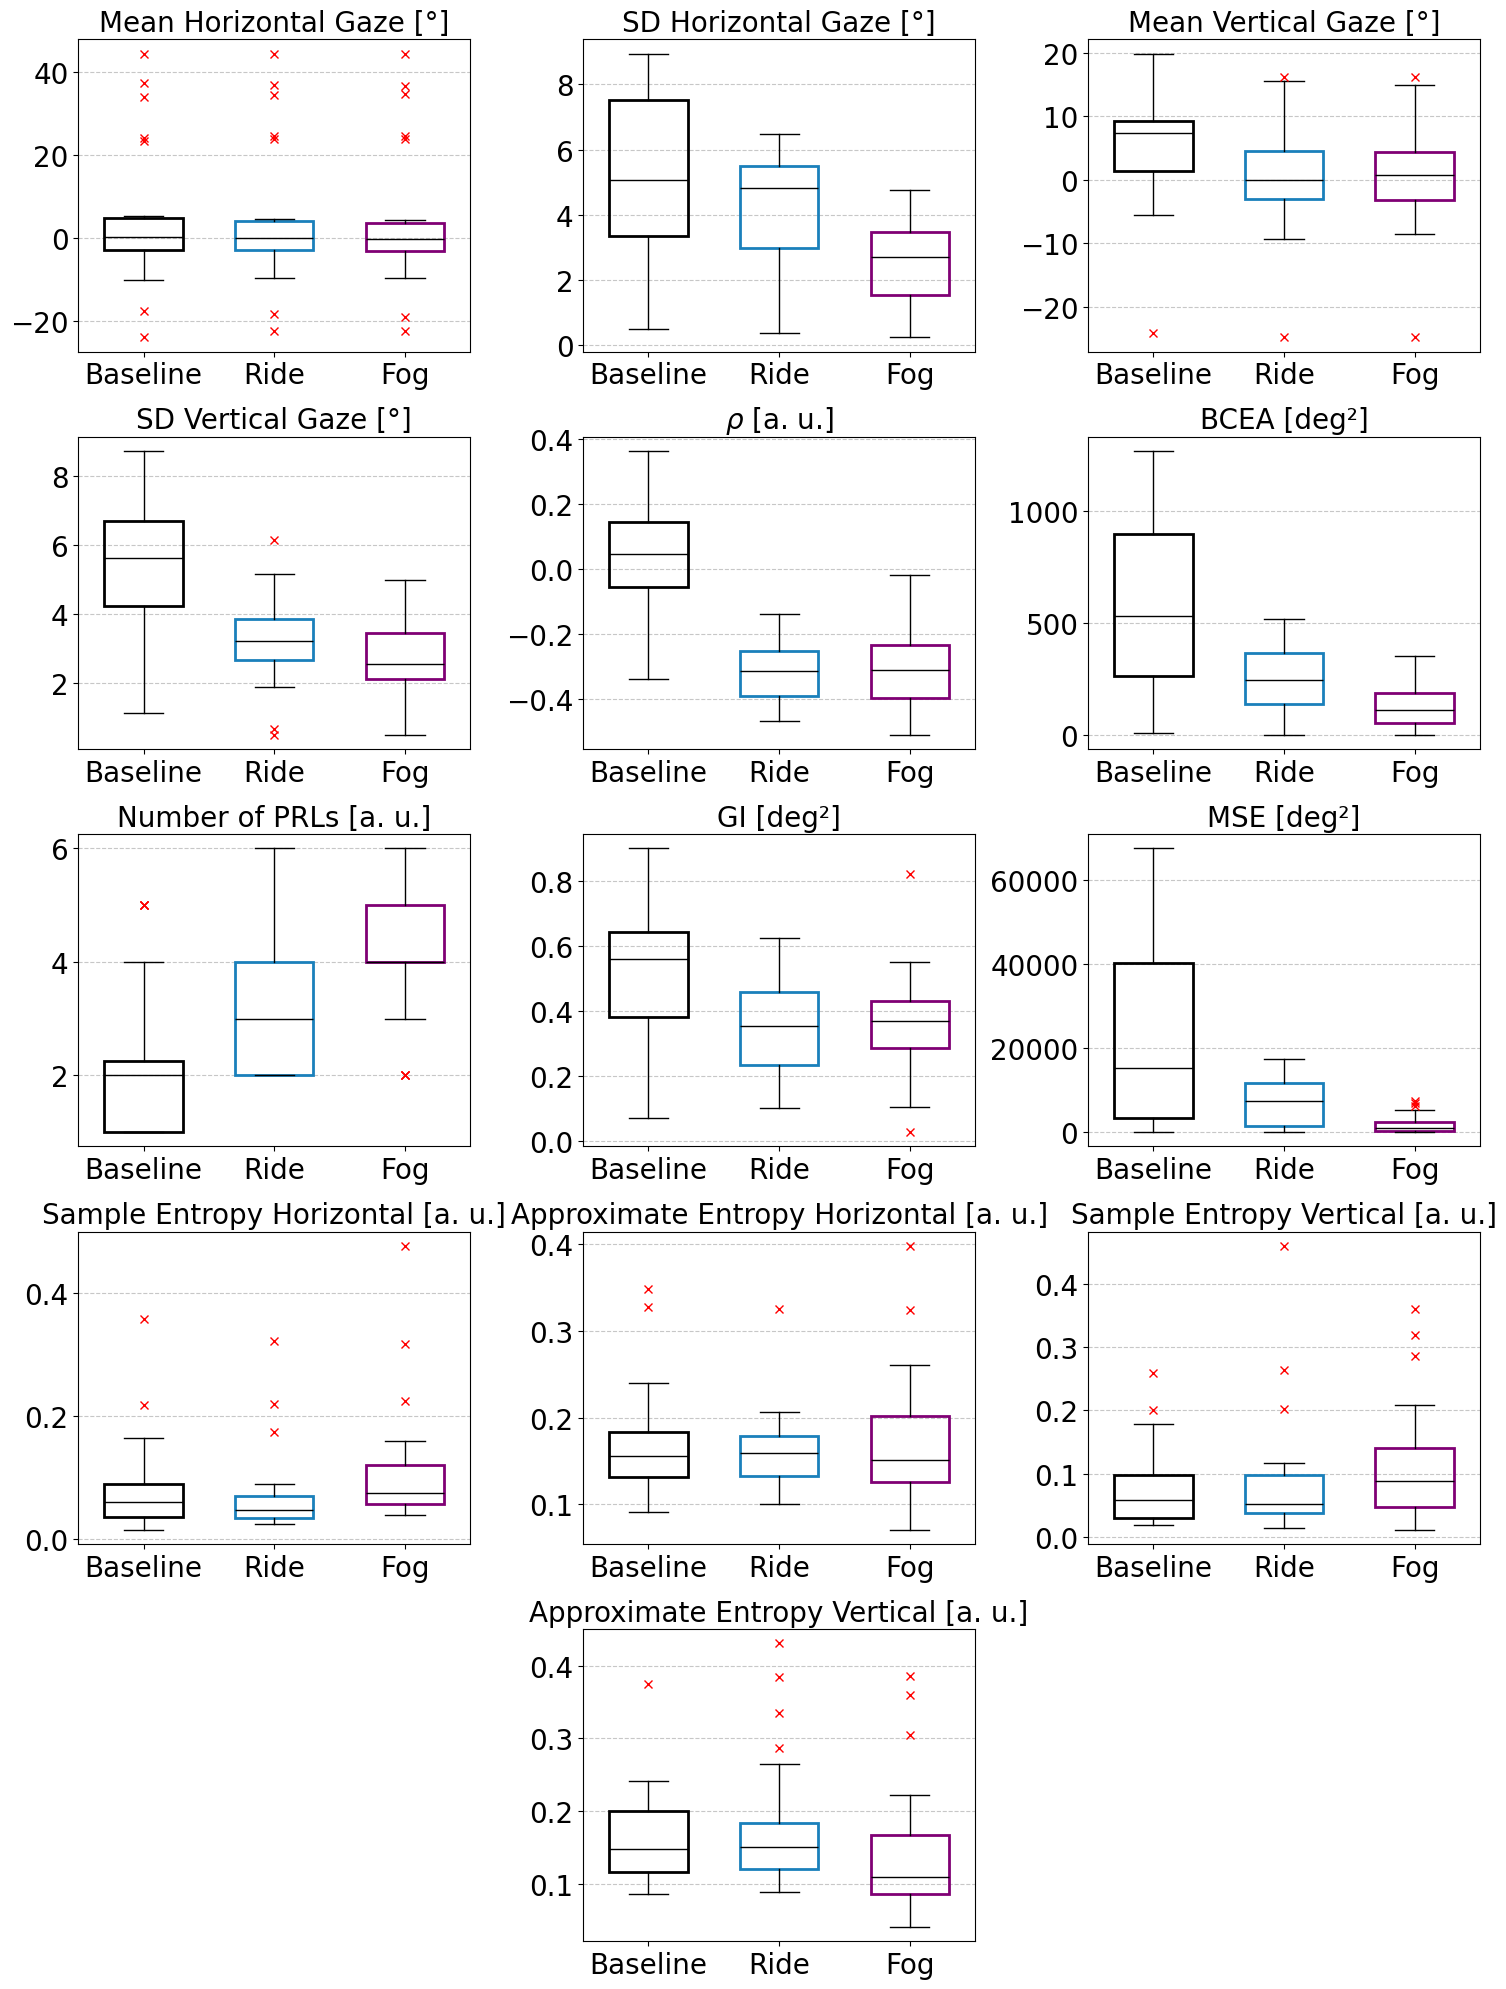

In [8]:
import matplotlib.pyplot as plt

variables = ['MeanHoriz','StdHoriz', 'MeanVert','StdVert', 'RHO', 'BCEA', 'Estimated PRL', 'Guziks Index',
             'MSE', 'Sample Entropy Horiz', 'App Entropy Horiz', 'Sample Entropy Vert', 'App Entropy Vert']

custom_titles = [
    'Mean Horizontal Gaze [°]',
    'SD Horizontal Gaze [°]',
    'Mean Vertical Gaze [°]',
    'SD Vertical Gaze [°]',
    '$\\rho$ [a. u.]',
    'BCEA [deg²]',
    'Number of PRLs [a. u.]',
    'GI [deg²]',
    'MSE [deg²]',
    'Sample Entropy Horizontal [a. u.]',
    'Approximate Entropy Horizontal [a. u.]',
    'Sample Entropy Vertical [a. u.]',
    'Approximate Entropy Vertical [a. u.]'
]

n_vars = len(variables)
n_cols = 3
n_rows = 5

fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, n_rows * 4))
axes_flat = axes.flatten()

# prvo uklonimo sve prazne axes
for i in range(n_rows * n_cols):
    axes_flat[i].set_visible(False)

# crtamo varijable
for i, var in enumerate(variables):
    # poslednja varijabla ide u sredinu poslednjeg reda
    if i == n_vars-1:
        ax = axes_flat[(n_rows-1)*n_cols + n_cols//2]
    else:
        ax = axes_flat[i]
    
    ax.set_visible(True)
    
    data = [baseline[var].dropna(), ride[var].dropna(), fog[var].dropna()]
    positions = [1, 2, 3]
    
    bplot = ax.boxplot(
        data,
        positions=positions,
        widths=0.6,
        patch_artist=True,
        showfliers=True,
        flierprops=dict(marker='x', markerfacecolor='red', markeredgecolor='red', markersize=6),
        medianprops=dict(color='black')
    )
    
    colors = ["#000000", '#1a80bb', '#800074']
    for patch, color in zip(bplot['boxes'], colors):
        patch.set_facecolor('none')
        patch.set_edgecolor(color)
        patch.set_linewidth(2)
    
    ax.set_xticks(positions)
    ax.set_xticklabels(['Baseline', 'Ride', 'Fog'], fontsize=20)
    ax.tick_params(axis='y', labelsize=20)
    ax.set_title(custom_titles[i], fontsize=20)
    ax.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.savefig('BCEA_Boxplot.jpg', dpi=300)
plt.show()


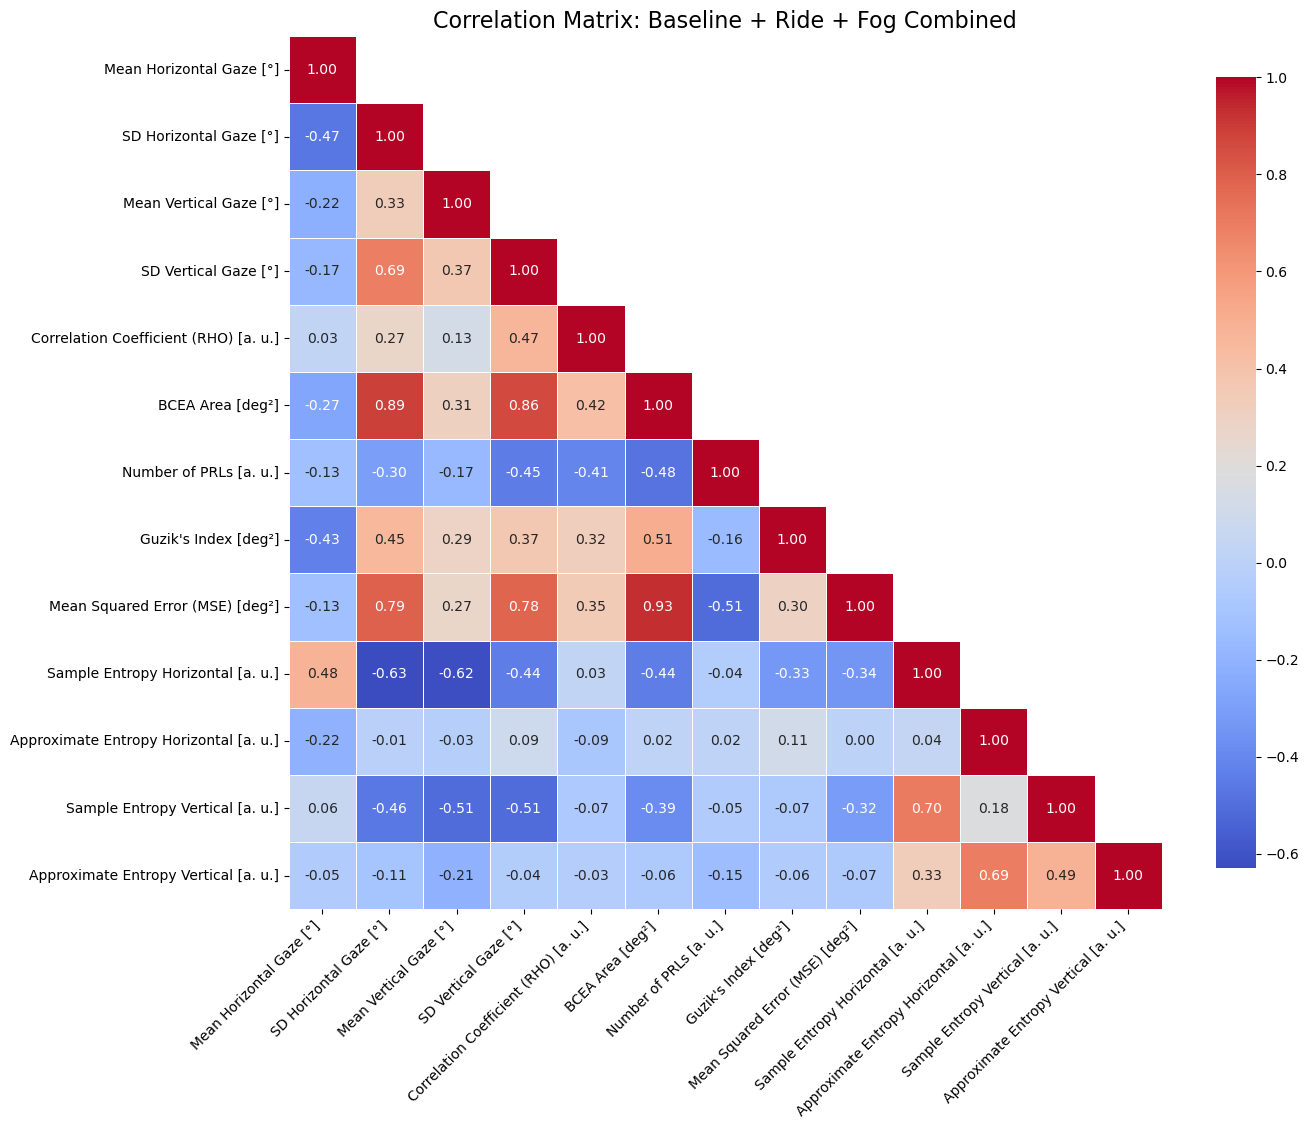

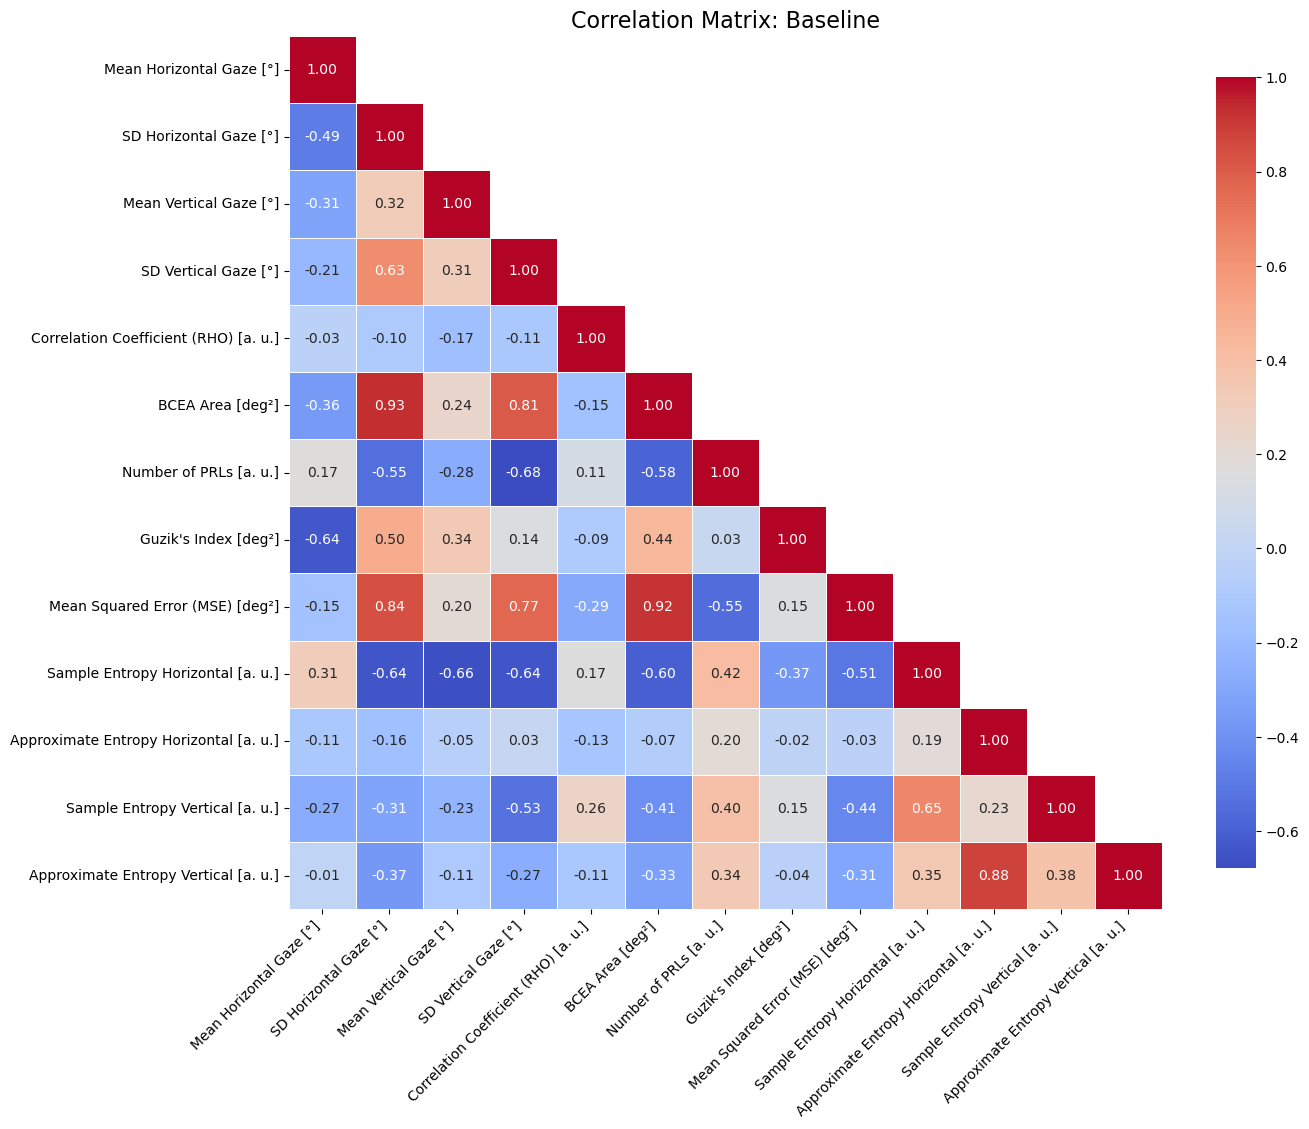

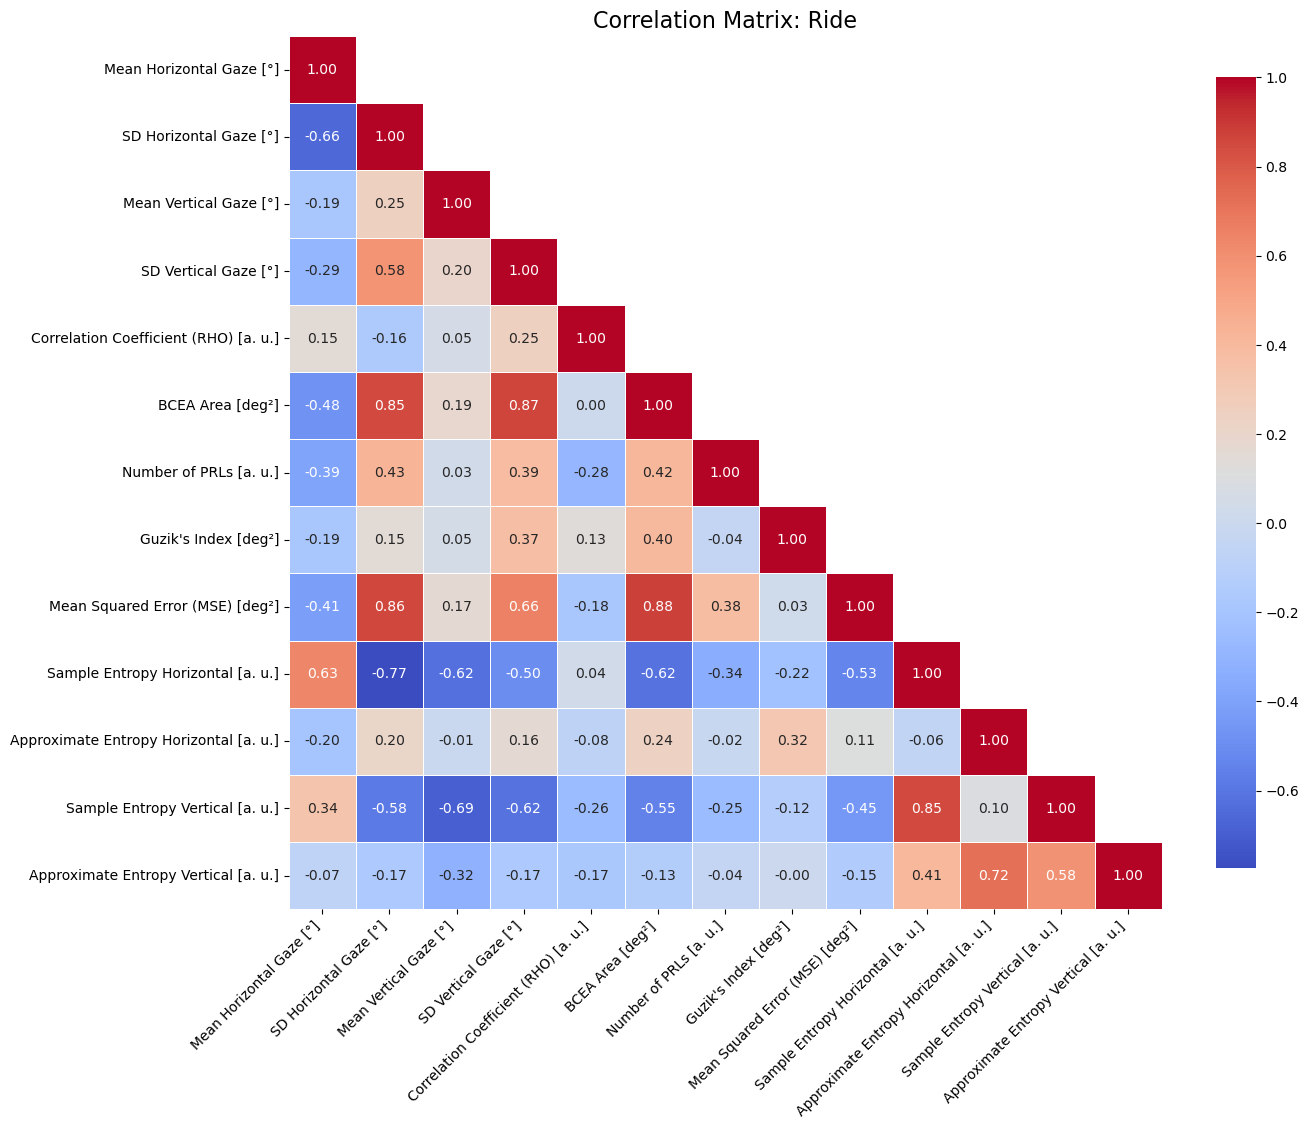

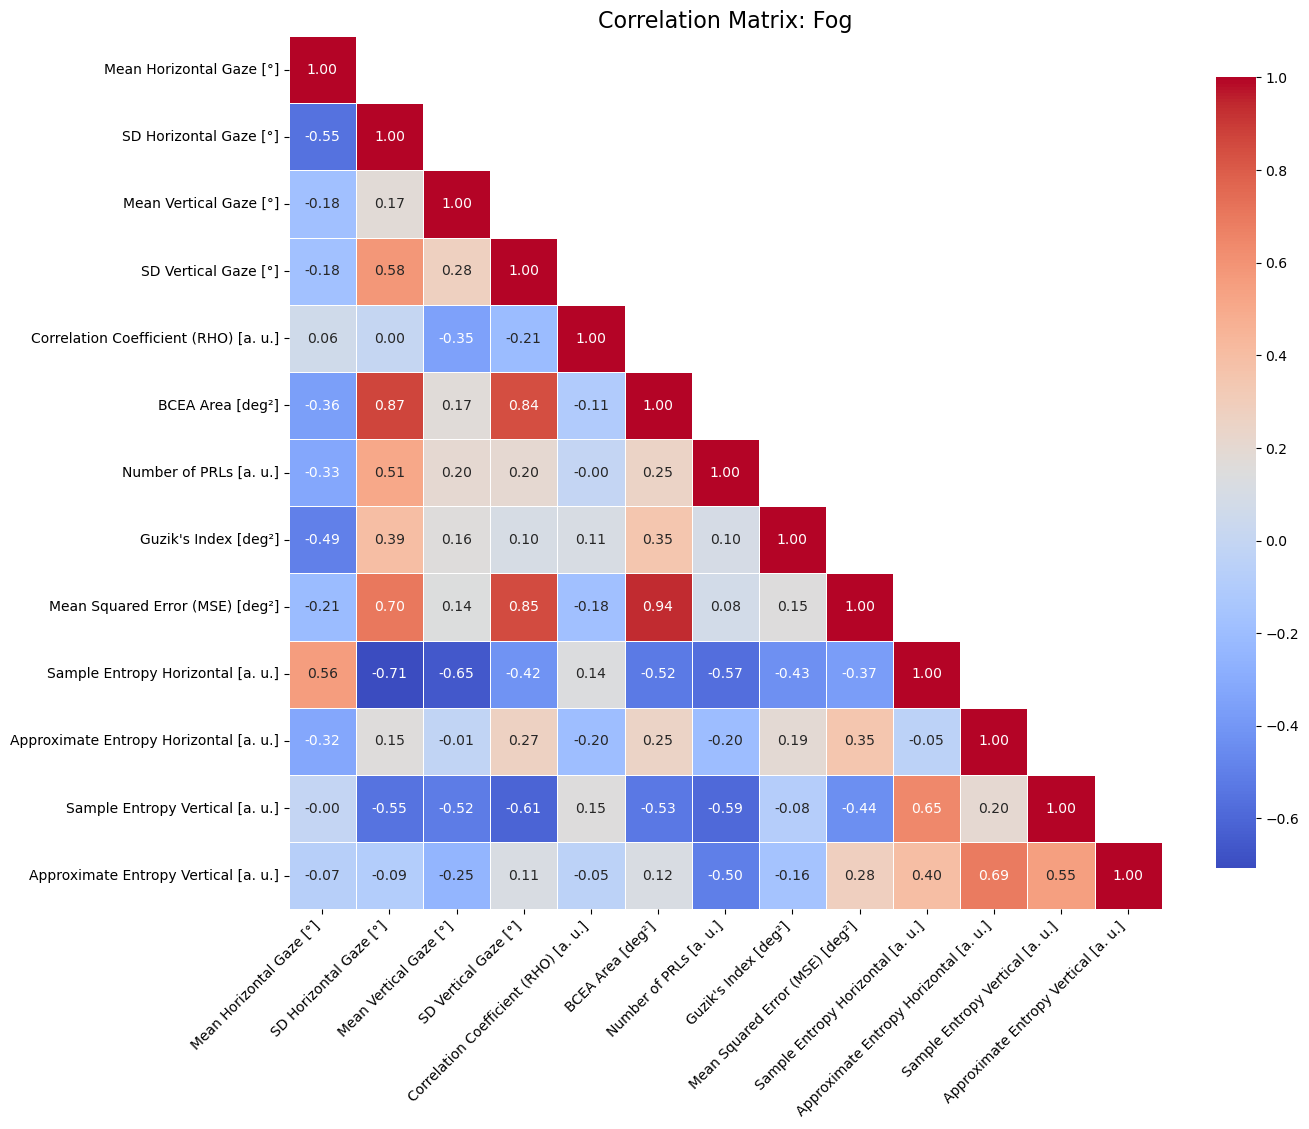

In [9]:
custom_titles = [
    'Mean Horizontal Gaze [°]',
    'SD Horizontal Gaze [°]',
    'Mean Vertical Gaze [°]',
    'SD Vertical Gaze [°]',
    'Correlation Coefficient (RHO) [a. u.]',
    'BCEA Area [deg²]',
    'Number of PRLs [a. u.]',
    'Guzik\'s Index [deg²]',
    'Mean Squared Error (MSE) [deg²]',
    'Sample Entropy Horizontal [a. u.]',
    'Approximate Entropy Horizontal [a. u.]',
    'Sample Entropy Vertical [a. u.]',
    'Approximate Entropy Vertical [a. u.]'
]

def plot_lower_triangle(corr_matrix, title, filename):
    
    mask = np.triu(np.ones_like(corr_matrix, dtype=bool),k=1)
    plt.figure(figsize=(14, 12))
    sns.heatmap(
        corr_matrix, 
        mask=mask, 
        cmap=cmap, 
        annot=True, 
        fmt=".2f", 
        linewidths=.5,
        square=True, 
        cbar_kws={"shrink": .8}, 
        xticklabels=[label.replace('_', ' ') for label in custom_titles],
        yticklabels=[label.replace('_', ' ') for label in custom_titles]
    )
    plt.title(title, fontsize=16)
    plt.xticks(rotation=45, ha='right')
    plt.yticks(rotation=0)
    plt.tight_layout()
    plt.savefig(filename, dpi=300)
    plt.show()
    plt.close()

# Plot and save
plot_lower_triangle(corr_combined, 'Correlation Matrix: Baseline + Ride + Fog Combined', 'BCEA_combined.jpg')
plot_lower_triangle(corr_baseline, 'Correlation Matrix: Baseline', 'BCEA_baseline.jpg')
plot_lower_triangle(corr_ride, 'Correlation Matrix: Ride', 'BCEA_ride.jpg')
plot_lower_triangle(corr_fog, 'Correlation Matrix: Fog', 'BCEA_fog.jpg')